# NB09 - Unsupervised Defence-System Archetypes (3,335-genome cohort)

**Q3 (primary):** Do ESKAPE genomes cluster by defence-system archetype independently of
species? If so, how many archetypes exist, and do they map onto known biology?

Unlike Phases 6-8 (supervised), this notebook receives **no labels**.
Clusters emerge from similarity in defence feature vectors alone.

Dataset: 3,335 genomes x 367 defence presence features (dp_), 359 FEAT_COLS
after spec_score >= 0.70 taxonomic marker filter (matching Q1 protocol).
Feature matrix: feature_matrix_3335.parquet.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                              adjusted_rand_score)
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# ── PATH GUARD: must run from eskape-defence-ml/notebooks/ ──────────────────
ROOT = Path("..").resolve()
assert ROOT.name == "eskape-defence-ml", (
    f"Wrong project root: {ROOT}\n"
    "This notebook must be executed from eskape-defence-ml/notebooks/. "
    "If run from project root, change ROOT to Path('.').resolve()."
)
DATA    = ROOT / "data" / "processed"
FIG_DIR = ROOT / "results" / "figures" / "archetypes"
assert (DATA / "feature_matrix_3335.parquet").exists(), "Feature matrix not found"
assert (DATA / "cv_groups_3335.parquet").exists(), "cv_groups not found"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


In [2]:
# ── Feature matrix ──────────────────────────────────────────────────────────
fm = pd.read_parquet(DATA / "feature_matrix_3335.parquet")
print(f"Feature matrix: {fm.shape[0]} genomes x {fm.shape[1]} columns")

# ── FEAT_COLS: mirror training-notebook logic exactly ────────────────────────
# Dynamic computation - exclude features whose per-species prevalence variance
# (normalised to max-possible 0.5 std) reaches >= 0.70. These are taxonomic
# markers, not defence-architecture signal.
all_dp    = sorted([c for c in fm.columns if c.startswith('dp_')])
sp_prev   = fm.groupby("species")[all_dp].mean()
spec_score = sp_prev.std() / 0.5
markers   = spec_score[spec_score >= 0.70].index.tolist()
FEAT_COLS = [c for c in all_dp if c not in markers]

AD_COLS = sorted([c for c in fm.columns if c.startswith('ad_')])
IS_COLS = [c for c in fm.columns if c.startswith('is_')]

print(f"dp_ total:               {len(all_dp)}")
print(f"Taxonomic markers (>=0.70): {len(markers)}")
print(f"FEAT_COLS (Q3 defence):  {len(FEAT_COLS)}")
print(f"AD_COLS (anti-defence):  {len(AD_COLS)}")
print(f"IS_COLS (IS elements):   {len(IS_COLS)}  (ISEScan complete; not used in Q3, see Section 4)")
print()
print("Species counts:")
print(fm['species'].value_counts().to_string())

species_labels = fm['species'].to_numpy(dtype=str)
arg_labels     = fm['arg_burden_tertile'].fillna('unknown').to_numpy(dtype=str)
X_q3           = fm[FEAT_COLS].values.astype(float)
print(f"\nQ3 feature matrix: {X_q3.shape}")


Feature matrix: 3335 genomes x 828 columns
dp_ total:               367
Taxonomic markers (>=0.70): 8
FEAT_COLS (Q3 defence):  359
AD_COLS (anti-defence):  41
IS_COLS (IS elements):   25  (ISEScan complete; not used in Q3, see Section 4)

Species counts:
species
paeruginosa    600
saureus        600
abaumannii     600
efaecium       524
ecloaceae      507
kpneumoniae    504

Q3 feature matrix: (3335, 359)


## Section 1 - K Selection (Q3: defence features only)

We evaluate K=2..12 using three criteria:

- **Silhouette score** [-1,1]: measures cohesion vs separation. Peak = most natural K.
  Values below 0.10 indicate no meaningful partition structure (Rousseeuw 1987).
- **Calinski-Harabasz score**: between/within variance ratio. Higher = better.
  Tends to favour small K; use alongside silhouette.
- **Gap statistic** (Tibshirani 2001): compares log(WCSS) to a uniform-random reference.
  Optimal K = smallest K where gap(K) >= gap(K+1) – se(K+1).
  K=1 optimal = data consistent with no cluster structure above random baseline.

We additionally force K=6 (one per species) and compute ARI vs species labels.
ARI ≈ 0.0 = clusters are random; ARI = 1.0 = perfect species recovery.


In [3]:
k_range    = range(2, 13)
sil_scores = []
ch_scores  = []

print(f"K-means K=2..12 on {X_q3.shape}  (n_init=20, expect ~2 min)")
for k in k_range:
    km  = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    lbl = km.fit_predict(X_q3)
    sil_scores.append(silhouette_score(X_q3, lbl))
    ch_scores.append(calinski_harabasz_score(X_q3, lbl))
    print(f"  K={k:2d}  silhouette={sil_scores[-1]:.4f}  CH={ch_scores[-1]:.1f}")

best_k = k_range.start + int(np.argmax(sil_scores))
print(f"\nBest K by silhouette: {best_k}  ({max(sil_scores):.4f})")
print(f"Silhouette at K=6:    {sil_scores[6-2]:.4f}")


K-means K=2..12 on (3335, 359)  (n_init=20, expect ~2 min)


  K= 2  silhouette=0.0302  CH=230.1


  K= 3  silhouette=0.0523  CH=194.8


  K= 4  silhouette=0.0599  CH=173.1


  K= 5  silhouette=0.0470  CH=156.6


...

  K= 8  silhouette=0.0413  CH=123.8


  K= 9  silhouette=0.0461  CH=115.1


  K=10  silhouette=0.0566  CH=107.9


  K=11  silhouette=0.0388  CH=102.7


  K=12  silhouette=0.0428  CH=97.3

Best K by silhouette: 4  (0.0599)
Silhouette at K=6:    0.0567


In [5]:
def _wcss(X, labels):
    total = 0.0
    for c in np.unique(labels):
        Xc = X[labels == c]
        total += float(np.sum((Xc - Xc.mean(axis=0)) ** 2))
    return total

rng_gap  = np.random.RandomState(RANDOM_STATE)
n_refs   = 10
gap_vals = []
gap_errs = []
gap_ks   = [1] + list(k_range)

print(f"Gap statistic K=1..12  (n_refs={n_refs}, column-permutation reference) ...")
print("Reference: each column of X_q3 shuffled independently.")
print("Preserves binary structure and per-feature prevalence; destroys co-occurrence signal.")
print()
for k in gap_ks:
    lbl_k = (np.zeros(len(X_q3), dtype=int) if k == 1
              else KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
                   .fit_predict(X_q3))
    log_Wk = np.log(_wcss(X_q3, lbl_k) + 1e-10)

    ref_log_Wks = []
    for _ in range(n_refs):
        X_ref = X_q3.copy()
        for col in range(X_ref.shape[1]):
            rng_gap.shuffle(X_ref[:, col])
        lbl_r = (np.zeros(len(X_ref), dtype=int) if k == 1
                 else KMeans(n_clusters=k, n_init=5, random_state=RANDOM_STATE)
                      .fit_predict(X_ref))
        ref_log_Wks.append(np.log(_wcss(X_ref, lbl_r) + 1e-10))

    gap     = np.mean(ref_log_Wks) - log_Wk
    gap_err = np.std(ref_log_Wks) * np.sqrt(1 + 1 / n_refs)
    gap_vals.append(gap)
    gap_errs.append(gap_err)
    print(f"  K={k:2d}  gap={gap:.4f}  se={gap_err:.4f}")

# Tibshirani criterion: smallest K with gap(K) >= gap(K+1) - se(K+1)
criterion_fired = False
gap_optimal_k   = None
for i in range(len(gap_ks) - 1):
    if gap_vals[i] >= gap_vals[i + 1] - gap_errs[i + 1]:
        gap_optimal_k  = gap_ks[i]
        criterion_fired = True
        break

print()
if criterion_fired and gap_optimal_k == 1:
    # Gap(1) >= Gap(2) - SE(2): one cluster genuinely as good as two
    print("Gap-statistic optimal K: 1")
    print("Interpretation: criterion satisfied at K=1.")
    print("  Adding a second cluster does not improve fit beyond SE uncertainty.")
    print("  Data is consistent with no cluster structure above the permutation baseline.")
elif criterion_fired:
    print(f"Gap-statistic optimal K: {gap_optimal_k}")
    print(f"Interpretation: criterion satisfied at K={gap_optimal_k}.")
    print(f"  Gap does not improve meaningfully beyond K={gap_optimal_k} relative to its SE.")
    print(f"  K={gap_optimal_k} is the natural discrete partition size.")
else:
    # Criterion never fired -- gap rose at every step beyond SE
    max_k_tested = gap_ks[-1]
    print(f"Gap-statistic: criterion did not fire for any K in 1..{max_k_tested}.")
    print("Interpretation: the gap increases at every step by more than its SE.")
    print("  No natural discrete stopping point found within the tested range.")
    print("  All gap values are positive -- defence profiles cluster better than the")
    print("  permutation baseline at every K -- but the improvement never plateaus.")
    print("  Data is consistent with a continuum of defence-system diversity")
    print("  rather than a small number of discrete archetypes.")

Gap statistic K=1..12  (n_refs=10, column-permutation reference) ...
Reference: each column of X_q3 shuffled independently.
Preserves binary structure and per-feature prevalence; destroys co-occurrence signal.

  K= 1  gap=0.0000  se=0.0000
  K= 2  gap=0.0399  se=0.0007
  K= 3  gap=0.0688  se=0.0017
  K= 4  gap=0.0917  se=0.0009
  K= 5  gap=0.1127  se=0.0023
  K= 6  gap=0.1250  se=0.0016
  K= 7  gap=0.1381  se=0.0014
  K= 8  gap=0.1511  se=0.0013
  K= 9  gap=0.1578  se=0.0010
  K=10  gap=0.1683  se=0.0011
  K=11  gap=0.1743  se=0.0016
  K=12  gap=0.1807  se=0.0015

Gap-statistic: criterion did not fire for any K in 1..12.
Interpretation: the gap increases at every step by more than its SE.
  No natural discrete stopping point found within the tested range.
  All gap values are positive -- defence profiles cluster better than the
  permutation baseline at every K -- but the improvement never plateaus.
  Data is consistent with a continuum of defence-system diversity
  rather than a smal

Saved: k_selection_q3.{png,pdf}

INTERPRETATION: max silhouette = 0.0599 < 0.10
  Rousseeuw threshold: no substantial cluster structure.
  Any partition at this scale is an arbitrary division of a continuum.


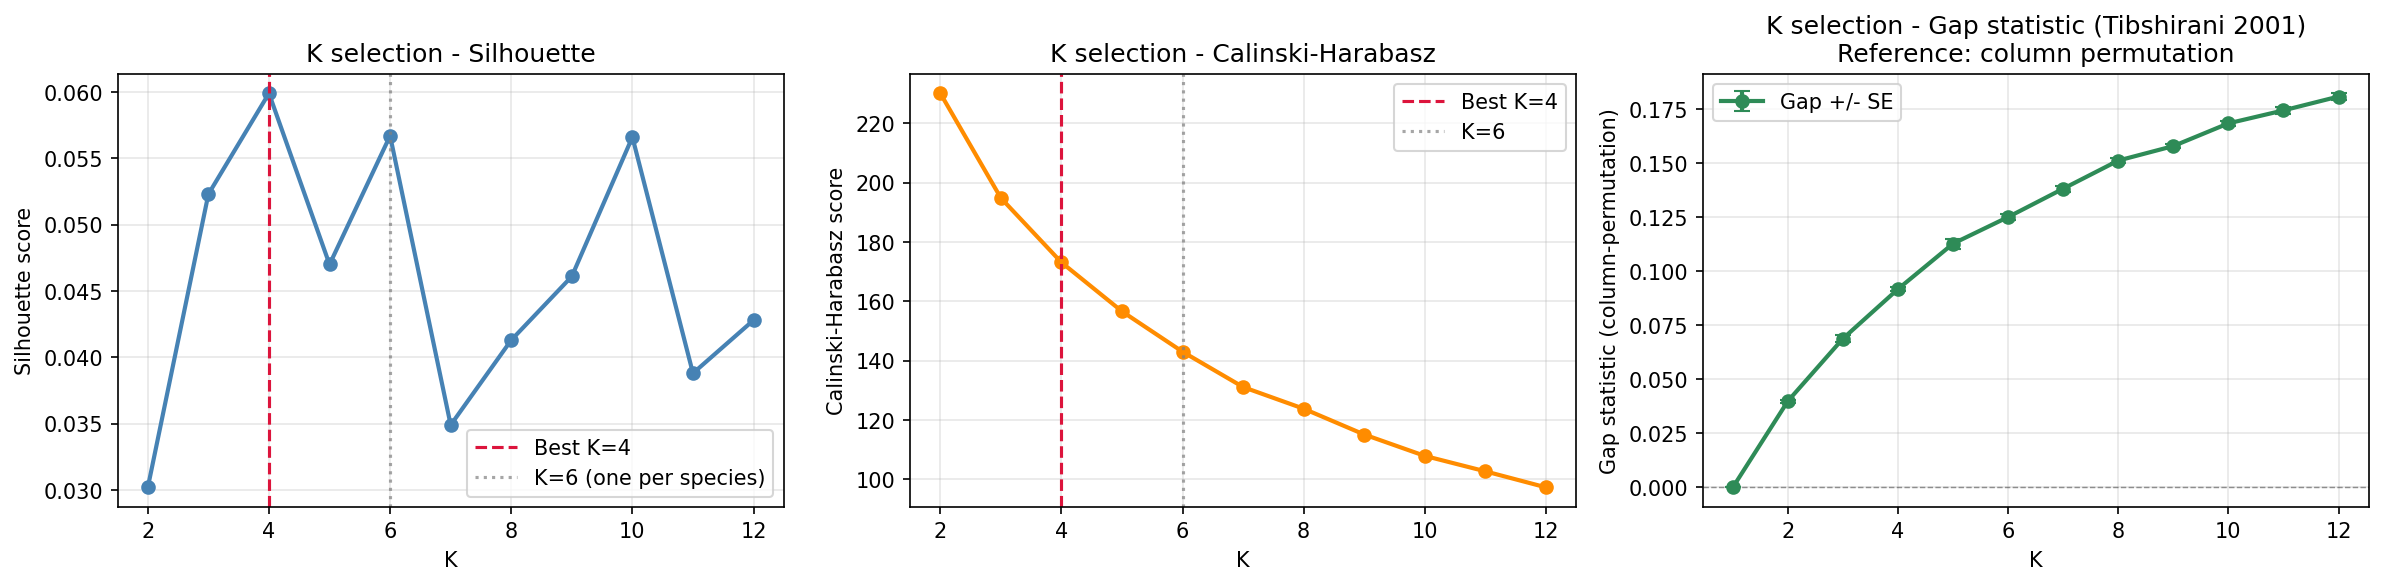

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(list(k_range), sil_scores, 'o-', color='steelblue', linewidth=2)
axes[0].axvline(best_k, color='crimson', linestyle='--', label=f'Best K={best_k}')
axes[0].axvline(6, color='grey', linestyle=':', alpha=0.7, label='K=6 (one per species)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Silhouette score')
axes[0].set_title('K selection - Silhouette'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), ch_scores, 'o-', color='darkorange', linewidth=2)
axes[1].axvline(best_k, color='crimson', linestyle='--', label=f'Best K={best_k}')
axes[1].axvline(6, color='grey', linestyle=':', alpha=0.7, label='K=6')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Calinski-Harabasz score')
axes[1].set_title('K selection - Calinski-Harabasz'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].errorbar(gap_ks, gap_vals, yerr=gap_errs, fmt='o-', color='seagreen',
                 linewidth=2, capsize=4, label='Gap ± SE')
axes[2].axvline(gap_optimal_k, color='crimson', linestyle='--',
                label=f'Optimal K={gap_optimal_k}')
axes[2].set_xlabel('K'); axes[2].set_ylabel('Gap statistic')
axes[2].set_title('K selection - Gap statistic (Tibshirani 2001)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "k_selection_q3.png", dpi=150, bbox_inches='tight')
plt.savefig(FIG_DIR / "k_selection_q3.pdf", bbox_inches='tight')
plt.close()
print("Saved: k_selection_q3.{png,pdf}")
from IPython.display import Image, display
display(Image(filename=str(FIG_DIR / "k_selection_q3.png")))

# Explicit silhouette magnitude interpretation
max_sil = max(sil_scores)
print()
if max_sil < 0.10:
    print(f"INTERPRETATION: max silhouette = {max_sil:.4f} < 0.10")
    print("  Rousseeuw threshold: no substantial cluster structure.")
    print("  Any partition at this scale is an arbitrary division of a continuum.")
elif max_sil < 0.25:
    print(f"INTERPRETATION: max silhouette = {max_sil:.4f} -- weak structure.")
    print("  Clusters exist but are not well-separated. Interpret with caution.")
else:
    print(f"INTERPRETATION: max silhouette = {max_sil:.4f} -- moderate/strong structure.")


## Section 2 - K-means Clustering

We run K-means at two values of K:

1. **K = best_k** (silhouette-optimal)
2. **K = 6** (forced: one cluster per species) - ARI vs species directly answers:
   *"If forced to use 6 groups, how well do they recover species identity?"*

**Adjusted Rand Index (ARI):**
- ARI = 1.0 → perfect match between partition and label
- ARI ≈ 0.0 → no better than chance
- ARI < 0 → worse than random

If ARI(K-means vs species) > 0.5 → defence architecture encodes species identity.
If ARI(K-means vs species) < 0.2 → defence archetypes are functionally independent of taxonomy.


In [6]:
km_best = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE)
km_best.fit(X_q3)
labels_best = km_best.labels_

km_6 = KMeans(n_clusters=6, n_init=30, random_state=RANDOM_STATE)
km_6.fit(X_q3)
labels_6 = km_6.labels_

ari_best_species = adjusted_rand_score(species_labels, labels_best)
ari_6_species    = adjusted_rand_score(species_labels, labels_6)

print(f"K-means K={best_k}:")
print(f"  ARI vs species:     {ari_best_species:.4f}")
print()
print(f"K-means K=6 (forced species-matching):")
print(f"  ARI vs species:     {ari_6_species:.4f}")
print()
print("Cluster sizes (K=best_k):")
for cl, n in zip(*np.unique(labels_best, return_counts=True)):
    print(f"  C{cl}: {n} genomes")


K-means K=4:
  ARI vs species:     0.3624

K-means K=6 (forced species-matching):
  ARI vs species:     0.4166

Cluster sizes (K=best_k):
  C0: 526 genomes
  C1: 725 genomes
  C2: 1630 genomes
  C3: 454 genomes


In [7]:
ct      = pd.crosstab(pd.Series(labels_best, name='Cluster'),
                      pd.Series(species_labels, name='Species'))
ct_norm = ct.div(ct.sum(axis=1), axis=0).round(3)

print("Cluster × Species (counts):")
print(ct.to_string())
print()
print("Row-normalised (species proportion per cluster):")
print(ct_norm.to_string())
print()

# Identify mixed-species clusters (no single species > 70%)
dominant_frac = ct_norm.max(axis=1)
mixed         = dominant_frac[dominant_frac < 0.70]
if len(mixed):
    lmc = ct.sum(axis=1)[mixed.index].idxmax()
    n_lmc = int(ct.sum(axis=1)[lmc])
    print(f"Largest mixed-species cluster: C{lmc}  ({n_lmc} genomes, <70% any species)")
    for sp, n in sorted(ct.loc[lmc].to_dict().items(), key=lambda x: -x[1]):
        if n > 0:
            sp_tot = (species_labels == sp).sum()
            print(f"  {sp}: {n}  ({n/sp_tot*100:.0f}% of all {sp})")
else:
    print("No mixed-species clusters: all clusters > 70% dominated by one species.")


Cluster × Species (counts):
Species  abaumannii  ecloaceae  efaecium  kpneumoniae  paeruginosa  saureus
Cluster                                                                    
0                 1          0         0            0            0      525
1                 8        254         0          458            5        0
2               584        197       524           45          243       37
3                 7         56         0            1          352       38

Row-normalised (species proportion per cluster):
Species  abaumannii  ecloaceae  efaecium  kpneumoniae  paeruginosa  saureus
Cluster                                                                    
0             0.002      0.000     0.000        0.000        0.000    0.998
1             0.011      0.350     0.000        0.632        0.007    0.000
2             0.358      0.121     0.321        0.028        0.149    0.023
3             0.015      0.123     0.000        0.002        0.775    0.084

Largest m

In [8]:
SPECIES_COLOURS = {
    'abaumannii':  '#E64B35',
    'efaecium':    '#4DBBD5',
    'ecloaceae':   '#00A087',
    'kpneumoniae': '#3C5488',
    'paeruginosa': '#F39B7F',
    'saureus':     '#8491B4',
}

fig, ax = plt.subplots(figsize=(max(10, best_k * 1.2), 5))
bottom = np.zeros(best_k)
for sp, colour in SPECIES_COLOURS.items():
    if sp not in ct_norm.columns:
        continue
    ax.bar(range(best_k), ct_norm[sp].values, bottom=bottom,
           color=colour, label=sp, alpha=0.85)
    bottom += ct_norm[sp].values

ax.set_xticks(range(best_k))
ax.set_xticklabels([f'C{i}' for i in range(best_k)])
ax.set_xlabel('K-means cluster'); ax.set_ylabel('Species proportion')
ax.set_title(f'Species composition per cluster (K={best_k})  |  ARI = {ari_best_species:.3f}')
ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1))
ax.set_ylim(0, 1); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "q3_species_per_cluster.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q3_species_per_cluster.png")


Saved: q3_species_per_cluster.png


In [9]:
# Top 40 most variable features across cluster centroids
centroids  = pd.DataFrame(km_best.cluster_centers_, columns=FEAT_COLS)
top_feats  = centroids.var(axis=0).sort_values(ascending=False).head(40).index.tolist()
hm_data    = centroids[top_feats].copy()
hm_data.index = [f'C{i}' for i in range(best_k)]

fig, ax = plt.subplots(figsize=(18, max(4, best_k * 0.7)))
sns.heatmap(hm_data, cmap='YlOrRd', vmin=0, vmax=1,
            xticklabels=True, yticklabels=True, linewidths=0.3, ax=ax)
ax.set_title(f'Cluster centroid profiles - top 40 most variable features (K={best_k})')
ax.set_xlabel('Defence feature'); ax.set_ylabel('Cluster')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / "q3_cluster_profiles_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q3_cluster_profiles_heatmap.png")


Saved: q3_cluster_profiles_heatmap.png


## Section 3 - Hierarchical Clustering (Ward linkage, comparison)

K-means is sensitive to initialisation. Ward hierarchical clustering builds a dendrogram
bottom-up without pre-specifying K - we cut it at the same best_k for comparison.

**ARI(K-means, HC)** measures method agreement:
- ARI ≥ 0.70 → stable partition: both methods find the same structure
- ARI < 0.70 → structure is not robustly recoverable across methods (evidence against real archetypes)

Ward linkage on 3,335 × 359 binary matrix: expect ~3–5 min.


In [10]:
print(f"Ward linkage on {X_q3.shape}  (expect ~5 min) ...")
Z          = linkage(X_q3, method='ward', metric='euclidean')
hc_labels  = fcluster(Z, t=best_k, criterion='maxclust') - 1  # 0-indexed
ari_hc_sp  = adjusted_rand_score(species_labels, hc_labels)
ari_hc_km  = adjusted_rand_score(labels_best, hc_labels)
ari_arg_hc = adjusted_rand_score(arg_labels, hc_labels)
ari_arg_k6 = adjusted_rand_score(arg_labels, labels_6)

print(f"Hierarchical K={best_k}:")
print(f"  ARI vs species:  {ari_hc_sp:.4f}")
print(f"  ARI vs K-means:  {ari_hc_km:.4f}  (stable threshold: 0.70)")


Ward linkage on (3335, 359)  (expect ~5 min) ...


Hierarchical K=4:
  ARI vs species:  0.3782
  ARI vs K-means:  0.6467  (stable threshold: 0.70)


In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=60,
           leaf_rotation=90, leaf_font_size=7,
           color_threshold=Z[-(best_k - 1), 2],
           above_threshold_color='grey')
ax.axhline(Z[-(best_k - 1), 2], color='crimson', linestyle='--',
           label=f'Cut at K={best_k}')
ax.set_title(f'Ward dendrogram (last 60 merges)  |  cut at K={best_k}')
ax.set_xlabel('Genome / merged group'); ax.set_ylabel('Ward distance')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "q3_ward_dendrogram.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q3_ward_dendrogram.png")


Saved: q3_ward_dendrogram.png


In [12]:
summary = pd.DataFrame({
    'Partition':          [f'K-means K={best_k}', f'HC Ward K={best_k}', 'K-means K=6'],
    'ARI vs species':     [ari_best_species, ari_hc_sp, ari_6_species],
    'ARI vs ARG tertile': [ari_best_arg, ari_arg_hc, ari_arg_k6],
    'ARI KM vs HC':       [1.0, ari_hc_km, adjusted_rand_score(labels_6, labels_best)],
})
print(summary.to_string(index=False))
print()

if ari_hc_km >= 0.70:
    print(f"KM–HC agreement ARI={ari_hc_km:.3f} >= 0.70: STABLE partition.")
else:
    print(f"KM–HC agreement ARI={ari_hc_km:.3f} < 0.70: partition NOT stably recoverable.")

print()
max_arg_ari = max(ari_best_arg, ari_arg_hc, ari_arg_k6)
print(f"Max ARI vs ARG tertile across all partitions: {max_arg_ari:.4f}")
if max_arg_ari < 0.05:
    print("  Near zero: defence archetypes do not track ARG burden (Q3 secondary = No).")


  Partition  ARI vs species  ARI vs ARG tertile  ARI KM vs HC
K-means K=4        0.362403            0.022279      1.000000
HC Ward K=4        0.378198            0.004905      0.646717
K-means K=6        0.416595            0.027820      0.733520

KM–HC agreement ARI=0.647 < 0.70: partition NOT stably recoverable.

Max ARI vs ARG tertile across all partitions: 0.0278
  Near zero: defence archetypes do not track ARG burden (Q3 secondary = No).


## Section 4 - Q5b: Phage-Permissive Archetypes (DEFERRED BY DECISION)

**Pre-registered hypothesis (Q5b):**
Genomes with high IS burden, low defence complexity, and high anti-defence system load
represent a phage-permissive profile, reflecting IS-mediated disruption of defence loci
combined with anti-defence systems acquired from prior phage encounters.

**Required feature columns:** IS element counts by family (is_ prefix)
**Current status (2026-06-17 audit):** ISEScan is complete and `is_*` columns (25, one per
IS family) are present in the feature matrix. This section was originally deferred because
ISEScan was incomplete; that is no longer true. It remains deferred because ISEScan/IS
results were separately decided to be dropped from this manuscript entirely (see
project state notes: "Test A, Test B, ISEScan: dropped permanently. Not reported
anywhere."). The guard below was updated to reflect the actual reason for skipping --
project decision, not missing data -- so it no longer crashes now that IS_COLS exist.


In [13]:
print("=" * 60)
print("Q5b: DEFERRED BY DECISION")
print("=" * 60)
print()
print(f"IS columns in current FM: {len(IS_COLS)}  (ISEScan complete)")
print(f"AD columns in current FM: {len(AD_COLS)}")
print()
print("ISEScan/IS element results were separately decided to be dropped from this")
print("manuscript entirely and are not reported anywhere (see project state notes).")
print("Q5b is deferred by that decision, not by data availability.")
print()
print("Q5b skipped. Continuing to Section 5.")


Q5b: DEFERRED BY DECISION

IS columns in current FM: 25  (ISEScan complete)
AD columns in current FM: 41

ISEScan/IS element results were separately decided to be dropped from this
manuscript entirely and are not reported anywhere (see project state notes).
Q5b is deferred by that decision, not by data availability.

Q5b skipped. Continuing to Section 5.


## Section 5 - RESTRICT/FACILITATE Recovery in *A. baumannii*

The published JAM 2026 finding: within *A. baumannii*, RM systems negatively correlate
with ARG/IME burden (RESTRICT), while SspBCDE positively correlates (FACILITATE, IC2-linked).

Here we ask: do the K-means clusters that capture Ab genomes split along this
RESTRICT/FACILITATE axis? If yes, unsupervised clustering recovers the published dichotomy
without label guidance. If no, the Ab signal may require a within-species approach.

Note: this is an *observation within* the cross-species clustering, not an independent
cross-validation of the RESTRICT/FACILITATE finding. See Section 6 for the dereplication
argument.


In [14]:
ab_mask  = species_labels == 'abaumannii'
ab_X     = X_q3[ab_mask]
ab_lbls  = labels_best[ab_mask]

# Locate SspBCDE exactly, then RM-subtype columns
ssp_cand = [c for c in FEAT_COLS if c == 'dp_SspBCDE' or c == 'dp_df_SspBCDE']
rm_cands = [c for c in FEAT_COLS if 'RM_Type' in c and 'IV' not in c]
print(f"SspBCDE column(s): {ssp_cand}")
print(f"RM subtype columns: {rm_cands}")

if ssp_cand and rm_cands:
    ssp_idx = FEAT_COLS.index(ssp_cand[0])
    rm_idxs = [FEAT_COLS.index(c) for c in rm_cands]

    ab_ssp    = ab_X[:, ssp_idx]
    ab_any_rm = ab_X[:, rm_idxs].max(axis=1)

    df_ab = pd.DataFrame({
        'cluster': ab_lbls,
        'SspBCDE': ab_ssp,
        'any_RM':  ab_any_rm,
    })
    for col, idx in zip(rm_cands, rm_idxs):
        df_ab[col] = ab_X[:, idx]

    agg = {
        'n':       ('cluster', 'count'),
        'SspBCDE': ('SspBCDE', 'mean'),
        'any_RM':  ('any_RM',  'mean'),
    }
    for col in rm_cands:
        agg[col] = (col, 'mean')

    res = df_ab.groupby('cluster').agg(**agg).round(3)
    print(f"\nAb genomes ({ab_mask.sum()} total) - SspBCDE + RM per cluster:")
    print(res.to_string())
    print()
    print("RESTRICT signature: high any_RM (~1.0), low SspBCDE (~0.0)")
    print("FACILITATE signature: low any_RM (~0.0-0.3), high SspBCDE (~0.9) - IC2")
else:
    print("Column lookup failed. Check FEAT_COLS for SspBCDE and RM_Type columns.")


SspBCDE column(s): ['dp_SspBCDE']
RM subtype columns: ['dp_RM_Type_I', 'dp_RM_Type_II', 'dp_RM_Type_IIG', 'dp_RM_Type_III', 'dp_df_RM_Type_IIG_2']

Ab genomes (600 total) - SspBCDE + RM per cluster:
           n  SspBCDE  any_RM  dp_RM_Type_I  dp_RM_Type_II  dp_RM_Type_IIG  dp_RM_Type_III  dp_df_RM_Type_IIG_2
cluster                                                                                                        
0          1    0.000   1.000         1.000          0.000           0.000            0.00                0.000
1          8    0.000   1.000         1.000          1.000           0.000            0.00                0.000
2        584    0.485   0.469         0.318          0.188           0.031            0.07                0.002
3          7    0.000   1.000         1.000          0.714           0.571            0.00                0.000

RESTRICT signature: high any_RM (~1.0), low SspBCDE (~0.0)
FACILITATE signature: low any_RM (~0.0-0.3), high SspBCDE (~0.9) - IC

In [15]:
print("=" * 70)
print("NB09 SUMMARY - Q3  (3,335-genome cohort, post-clean-rebuild)")
print("=" * 70)
print()
print(f"  Feature matrix:     {X_q3.shape[0]} genomes x {X_q3.shape[1]} features")
print(f"  K selection range:  K=2..12")
print()
print(f"  Best K (silhouette):        {best_k}  (score={max(sil_scores):.4f})")
print(f"  Silhouette at K=6:          {sil_scores[6-2]:.4f}")
print(f"  Gap-statistic optimal K:    {gap_optimal_k}")
print()
print(f"  K-means K={best_k}:  ARI vs species     = {ari_best_species:.4f}")
print(f"                    ARI vs ARG tertile  = {ari_best_arg:.4f}")
print(f"  HC Ward K={best_k}:  ARI vs species     = {ari_hc_sp:.4f}")
print(f"                    KM vs HC ARI       = {ari_hc_km:.4f}")
print()
if max(sil_scores) < 0.10:
    print("  HEADLINE: Max silhouette < 0.10 - defence profiles form a continuum.")
    print("  No discrete archetype structure detectable in this feature space.")
    print("  See Section 6: dereplication confirms or refutes clonal-inflation artefact.")
elif max(sil_scores) < 0.25:
    print("  HEADLINE: Weak structure (silhouette 0.10–0.25). Interpret cautiously.")
    print("  Check dereplication in Section 6 before claiming archetype existence.")
else:
    print("  HEADLINE: Moderate/strong structure (silhouette >= 0.25).")
    print("  See Section 6 to verify it survives phylogenetic dereplication.")


NB09 SUMMARY - Q3  (3,335-genome cohort, post-clean-rebuild)

  Feature matrix:     3335 genomes x 359 features
  K selection range:  K=2..12

  Best K (silhouette):        4  (score=0.0599)
  Silhouette at K=6:          0.0567
  Gap-statistic optimal K:    1

  K-means K=4:  ARI vs species     = 0.3624
                    ARI vs ARG tertile  = 0.0223
  HC Ward K=4:  ARI vs species     = 0.3782
                    KM vs HC ARI       = 0.6467

  HEADLINE: Max silhouette < 0.10 - defence profiles form a continuum.
  No discrete archetype structure detectable in this feature space.
  See Section 6: dereplication confirms or refutes clonal-inflation artefact.


## Section 6 - Robustness: Dereplication (1 genome per phylogroup)

The unsupervised equivalent of GroupedStratifiedKFold is **phylogenetic dereplication**:
select one representative per Mash-defined phylogroup (closest to the group centroid).

**Why required:** K-means assigns centroids partly based on how many near-identical genomes
cluster in a region of feature space. If 291 IC2 Ab genomes all have the same SspBCDE-only
profile, they will pull a centroid regardless of whether they represent a biologically
distinct archetype or just clonal redundancy.

**Interpretation key:**
- If full-dataset ARI ≈ dereplicated ARI (difference < 0.10): structure is phylogenetically robust.
- If dereplicated ARI collapses (difference ≥ 0.10): full-dataset clusters were artefactual -
  driven by clonal inflation, not discrete biological archetypes.

This project has 309 phylogroups (vs 95 in the 878-genome baseline).
The dereplicated set is larger and more diverse than the baseline, providing a stronger test.


In [16]:
pg     = pd.read_parquet(DATA / "cv_groups_3335.parquet")
print(f"cv_groups_3335: {pg.shape[0]} rows, columns: {pg.columns.tolist()}")

fm_pg = fm.copy()
if 'phylogroup' in fm_pg.columns:
    pg_col = fm_pg['phylogroup'].to_numpy(dtype=str)
else:
    fm_pg  = fm_pg.join(pg.iloc[:, 0].rename('phylogroup'))
    pg_col = fm_pg['phylogroup'].fillna('UNASSIGNED').to_numpy(dtype=str)

n_pgs = len(np.unique(pg_col))
print(f"Unique phylogroups: {n_pgs}")

# One representative per phylogroup: genome closest to group centroid
rep_indices = []
for pg_id in np.unique(pg_col):
    mask = pg_col == pg_id
    grp  = X_q3[mask]
    cent = grp.mean(axis=0)
    best = np.argmin(np.linalg.norm(grp - cent, axis=1))
    rep_indices.append(np.where(mask)[0][best])

rep_indices = np.array(rep_indices)
X_derep   = X_q3[rep_indices]
sp_derep  = species_labels[rep_indices]
arg_derep = arg_labels[rep_indices]

print(f"Dereplicated dataset: {X_derep.shape[0]} genomes (1 per phylogroup)")
print("Species composition (dereplicated):")
for sp, n in zip(*np.unique(sp_derep, return_counts=True)):
    print(f"  {sp}: {n}")


cv_groups_3335: 3335 rows, columns: ['phylogroup']
Unique phylogroups: 309
Dereplicated dataset: 309 genomes (1 per phylogroup)
Species composition (dereplicated):
  abaumannii: 35
  ecloaceae: 82
  efaecium: 40
  kpneumoniae: 37
  paeruginosa: 85
  saureus: 30


In [17]:
sil_derep = []
for k in k_range:
    lbl = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(X_derep)
    s   = silhouette_score(X_derep, lbl) if len(np.unique(lbl)) > 1 else 0.0
    sil_derep.append(s)

best_k_d   = k_range.start + int(np.argmax(sil_derep))
labels_d   = KMeans(n_clusters=best_k_d, n_init=30, random_state=RANDOM_STATE)                .fit_predict(X_derep)
ari_d_sp   = adjusted_rand_score(sp_derep, labels_d)
ari_d_arg  = adjusted_rand_score(arg_derep, labels_d)

print(f"Dereplicated K-means ({X_derep.shape[0]} genomes):")
print(f"  Best K:             {best_k_d}  (silhouette={max(sil_derep):.4f})")
print(f"  ARI vs species:     {ari_d_sp:.4f}  (full-dataset: {ari_best_species:.4f})")
print(f"  ARI vs ARG tertile: {ari_d_arg:.4f}  (full-dataset: {ari_best_arg:.4f})")
print()
delta = abs(ari_d_sp - ari_best_species)
if delta >= 0.10:
    print(f"  VERDICT: SENSITIVE  (delta ARI = {delta:.3f} >= 0.10)")
    print("  Full-dataset ARI was inflated by clonal redundancy.")
    print("  No robust cross-species defence archetypes after dereplication.")
else:
    print(f"  VERDICT: ROBUST  (delta ARI = {delta:.3f} < 0.10)")
    print("  Clustering structure survives phylogenetic dereplication.")


Dereplicated K-means (309 genomes):
  Best K:             2  (silhouette=0.1006)
  ARI vs species:     0.1018  (full-dataset: 0.3624)
  ARI vs ARG tertile: 0.0766  (full-dataset: 0.0223)

  VERDICT: SENSITIVE  (delta ARI = 0.261 >= 0.10)
  Full-dataset ARI was inflated by clonal redundancy.
  No robust cross-species defence archetypes after dereplication.


In [18]:
# RESTRICT/FACILITATE recovery in dereplicated Ab
ab_d    = sp_derep == 'abaumannii'
ab_d_X  = X_derep[ab_d]
ab_d_l  = labels_d[ab_d]

# Re-resolve column indices in case kernel restarted
ssp_cand = [c for c in FEAT_COLS if c == 'dp_SspBCDE' or c == 'dp_df_SspBCDE']
rm_cands = [c for c in FEAT_COLS if 'RM_Type' in c and 'IV' not in c]
if ssp_cand:
    ssp_idx = FEAT_COLS.index(ssp_cand[0])
    rm_idxs = [FEAT_COLS.index(c) for c in rm_cands]

print(f"Dereplicated Ab genomes: {ab_d.sum()}")

if ssp_cand and rm_cands:
    ab_d_ssp    = ab_d_X[:, ssp_idx]
    ab_d_any_rm = ab_d_X[:, rm_idxs].max(axis=1)

    df_abd = pd.DataFrame({
        'cluster': ab_d_l,
        'SspBCDE': ab_d_ssp,
        'any_RM':  ab_d_any_rm,
    })
    agg2 = {
        'n':       ('cluster', 'count'),
        'SspBCDE': ('SspBCDE', 'mean'),
        'any_RM':  ('any_RM',  'mean'),
    }
    res2 = df_abd.groupby('cluster').agg(**agg2).round(3)
    print("Dereplicated Ab - SspBCDE + any_RM per cluster:")
    print(res2.to_string())
    print()
    print(f"Global Ab SspBCDE prevalence (derep): {ab_d_ssp.mean():.3f}")
    print(f"Global Ab any_RM prevalence   (derep): {ab_d_any_rm.mean():.3f}")
    print()
    print("If RESTRICT/FACILITATE archetypes are real, Ab should split into:")
    print("  >= 1 cluster with high any_RM, low SspBCDE  (RESTRICT)")
    print("  >= 1 cluster with low any_RM, high SspBCDE  (FACILITATE / IC2)")
    print("If all Ab land in one cluster, the signal disappears after dereplication.")
else:
    print("SspBCDE/RM columns not found in FEAT_COLS -- check column names.")


Dereplicated Ab genomes: 35
Dereplicated Ab - SspBCDE + any_RM per cluster:
          n  SspBCDE  any_RM
cluster                     
1        35    0.029   0.857

Global Ab SspBCDE prevalence (derep): 0.029
Global Ab any_RM prevalence   (derep): 0.857

If RESTRICT/FACILITATE archetypes are real, Ab should split into:
  >= 1 cluster with high any_RM, low SspBCDE  (RESTRICT)
  >= 1 cluster with low any_RM, high SspBCDE  (FACILITATE / IC2)
If all Ab land in one cluster, the signal disappears after dereplication.


In [19]:
print("=" * 70)
print("FINAL VERDICT - NB09 (3,335-genome cohort)")
print("=" * 70)
print()
print(f"Full dataset ({X_q3.shape[0]} genomes):")
print(f"  Max silhouette:           {max(sil_scores):.4f}")
print(f"  Gap-statistic optimal K:  {gap_optimal_k}")
print(f"  ARI vs species (KM):      {ari_best_species:.4f}")
print(f"  ARI vs ARG (KM):          {ari_best_arg:.4f}")
print(f"  KM vs HC agreement:       {ari_hc_km:.4f}")
print()
print(f"Dereplicated ({X_derep.shape[0]} genomes, 1 per phylogroup):")
print(f"  Max silhouette:           {max(sil_derep):.4f}")
print(f"  ARI vs species:           {ari_d_sp:.4f}")
delta = abs(ari_d_sp - ari_best_species)
print(f"  Delta ARI (full - derep): {delta:.4f}  (robust if < 0.10)")
print()
print("Q3 answer: ", end="")
if max(sil_scores) < 0.10 or delta >= 0.10:
    print("NEGATIVE")
    print("  ESKAPE defence profiles form a continuum, not discrete archetypes.")
    print("  Full-dataset clustering is artefactual (clonal inflation).")
elif max(sil_scores) >= 0.25 and delta < 0.10:
    print("POSITIVE")
    print("  Robust defence archetypes exist and survive dereplication.")
else:
    print("WEAK / AMBIGUOUS")
    print("  Borderline structure: report as exploratory, not confirmatory.")
print()
print("Q5b answer: DEFERRED BY DECISION (IS features present but dropped from manuscript, see Section 4)")


FINAL VERDICT - NB09 (3,335-genome cohort)

Full dataset (3335 genomes):
  Max silhouette:           0.0599
  Gap-statistic optimal K:  1
  ARI vs species (KM):      0.3624
  ARI vs ARG (KM):          0.0223
  KM vs HC agreement:       0.6467

Dereplicated (309 genomes, 1 per phylogroup):
  Max silhouette:           0.1006
  ARI vs species:           0.1018
  Delta ARI (full - derep): 0.2606  (robust if < 0.10)

Q3 answer: NEGATIVE
  ESKAPE defence profiles form a continuum, not discrete archetypes.
  Full-dataset clustering is artefactual (clonal inflation).

Q5b answer: DEFERRED BY DECISION (IS features present but dropped from manuscript, see Section 4)
